http://localhost:9090/api/v1/query_range?query=kepler_container_joules_total{namespace=%22monitoring%22,%20mode=%22dynamic%22}&start=2025-03-26T07:32:45Z&end=2025-03-26T11:30:13Z&step=60s

/tmp/ipykernel_2533/4142243525.py:31: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  datetime_series = [datetime.datetime.utcfromtimestamp(ts) for ts in sorted_timestamps]


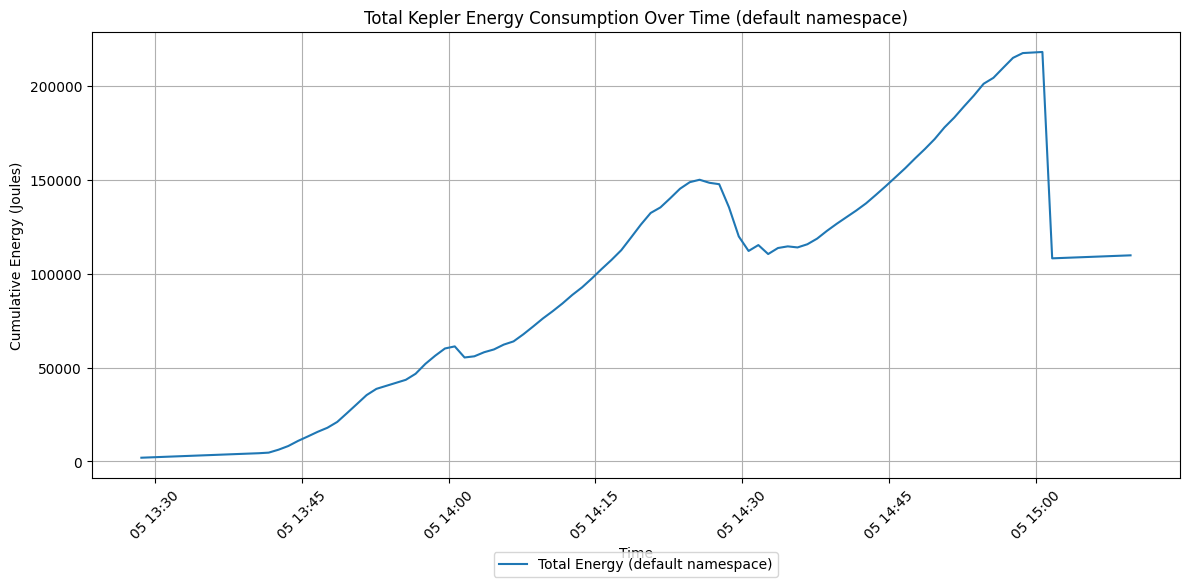

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load the JSON files
with open("hpa_2m/hpa_2m.json") as f1, open("deepscaler_30_5_hpa_2m/deepscaler_30_5.json") as f2:
    data1 = json.load(f1)
    data2 = json.load(f2)

# Helper function to extract cumulative energy data for the "default" namespace
def extract_energy_data(data):
    records = {}
    for item in data["data"]["result"]:
        if item["metric"].get("container_namespace") == "default":
            for timestamp, value in item["values"]:
                timestamp = int(timestamp)
                value = float(value)
                if timestamp not in records:
                    records[timestamp] = 0.0
                records[timestamp] += value
    return pd.Series(records).sort_index()

# Extract energy usage series
energy_series1 = extract_energy_data(data1)
energy_series2 = extract_energy_data(data2)

# Align both series on a unified index (ignoring actual timestamps)
min_length = min(len(energy_series1), len(energy_series2))
aligned_series1 = energy_series1.iloc[:min_length].reset_index(drop=True)
aligned_series2 = energy_series2.iloc[:min_length].reset_index(drop=True)
time_frame = range(min_length)

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(time_frame, aligned_series1, label='HPA No Preserve 2m')
plt.plot(time_frame, aligned_series2, label='DeepScaler 30/5')
plt.xlabel("Unified Timeframe (Index)")
plt.ylabel("Cumulative Energy Usage (Joules)")
plt.title("Total Energy Usage Over Time (Default Namespace)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2533/3157030477.py:22: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  timestamps = [datetime.datetime.utcfromtimestamp(int(ts)) for ts in timestamps]


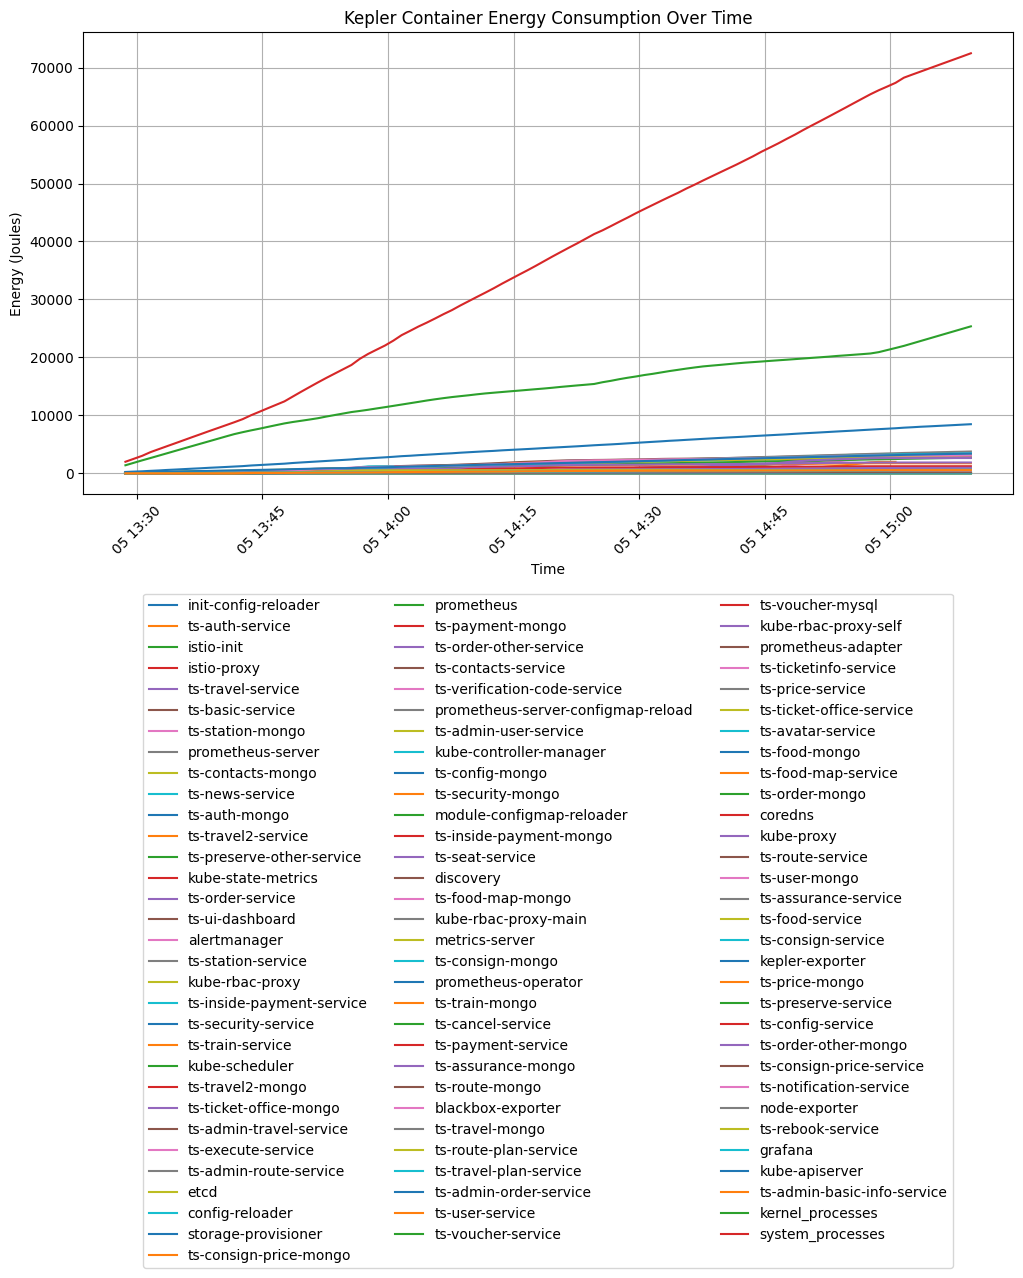

In [9]:
import json
import matplotlib.pyplot as plt
import datetime

# Load the JSON data
file_path = "hpa_30s_window/hpa_energy.json"
file_path = "deepscaler_2m_GLA_30_2/energy_deepscaler_2m_GLA_30_2.json"
file_path = "hpa_2m/hpa_2m.json"
#file_path = "no_hpa/energy_no_hpa.json"

with open(file_path, "r") as f:
    data = json.load(f)

# Extract time-series data
time_series = {}
for result in data["data"]["result"]:
    container_name = result["metric"].get("container_name", "unknown")
    values = result["values"]
    timestamps, energy_values = zip(*values)
    
    # Convert timestamps to readable datetime format
    timestamps = [datetime.datetime.utcfromtimestamp(int(ts)) for ts in timestamps]
    energy_values = [float(val) for val in energy_values]
    
    time_series[container_name] = (timestamps, energy_values)

# Plot the data similar to Prometheus visualization
plt.figure(figsize=(12, 6))
for container, (timestamps, energy_values) in time_series.items():
    plt.plot(timestamps, energy_values, label=container)

plt.xlabel("Time")
plt.ylabel("Energy (Joules)")
plt.title("Kepler Container Energy Consumption Over Time")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)  # Legend placed under the graph
plt.show()


/tmp/ipykernel_509500/2505754796.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


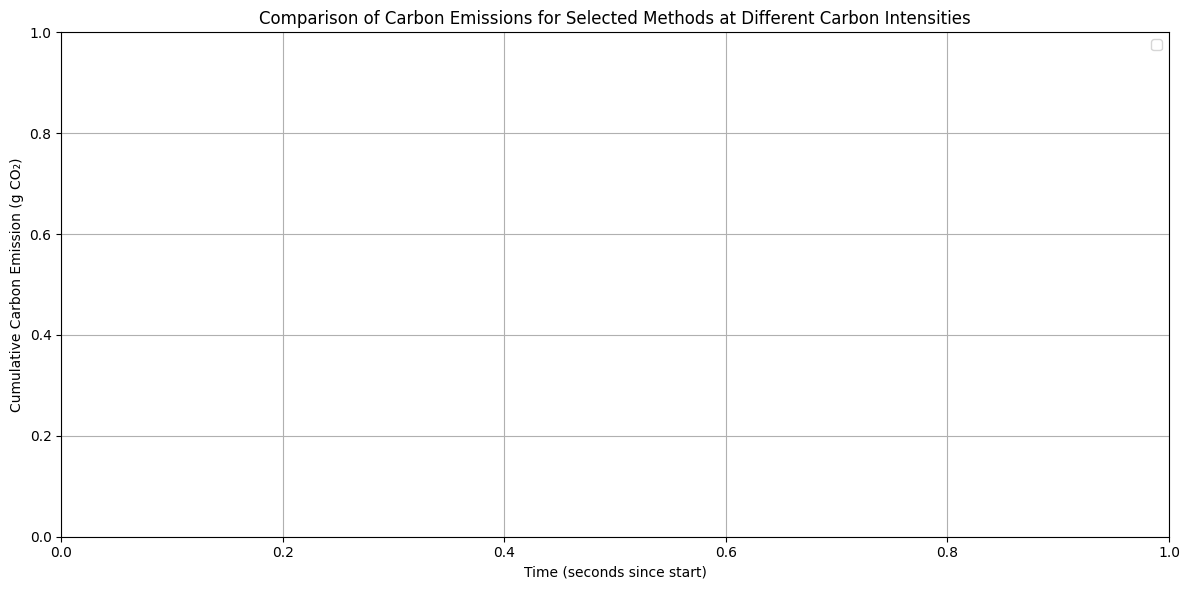

In [4]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# File paths and readable labels
file_paths = [
    "hpa_2m/kepler_data.json",
    "AdapGLA/AdapGLB_0.35_0/kepler_data.json",
    "AdapGLA/AdapGLB_0.35_1/kepler_data.json",
    "AdapGLA/AdapGLB_0.5_0/kepler_data.json",
    "AdapGLA/AdapGLB_0.5_1/kepler_data.json",
    "AdapGLA/AdapGLB_0.8_0/kepler_data.json",
    "AdapGLA/AdapGLB_0.8_1/kepler_data.json",
    # "AdapGLD/AdapGLD_0.4_0/kepler_data.json",
    # "AdapGLD/AdapGLD_0.5_1/kepler_data.json",
    # "AdapGLD/AdapGLD_0.8_0/kepler_data.json",
    # "AdapGLA_0/kepler_data.json",
    # "AdapGLA_30_5/kepler_data.json",
    # "AdapGLA_30_5_04/kepler_data.json",
    # "AdapGLA_30_5_05/kepler_data.json",
    # "AdapGLA_30_5_08/kepler_data.json",
    # "AdapGLT_0/kepler_data.json",
    # "AdapGLD_0/kepler_data.json"
]

labels = [
    "HPA",
    # "AdapGLA_0",
    # "AdapGLA t=0.35",
    # "AdapGLA t=0.4",
    # "AdapGLA t=0.5",
    # "AdapGLA t=0.8",
    # "AdapGLT t=0.35",
    # "AdapGLD t=0.35",
]
labels = file_paths

# Constants
JOULES_PER_KWH = 3_600_000
CARBON_INTENSITIES = [100, 250, 300]  # g/kWh

# Choose 1 config to represent each CI
CI_LABEL_MAP = {
    100: "HPA",
    250: "HPA",
    300: "HPA"
}

# Storage for emissions and durations
all_cum_emissions = {}
time_durations = {}

# Process each file
for file_path, label in zip(file_paths, labels):
    with open(file_path, "r") as f:
        data = json.load(f)

    prev_energy = defaultdict(float)
    energy_by_time = defaultdict(float)
    min_timestamp = float("inf")
    max_timestamp = float("-inf")

    for result in data["data"]["result"]:
        if result["metric"].get("container_namespace") != "default":
            continue

        pod = result["metric"].get("pod", "unknown")
        for ts_str, val_str in result["values"]:
            ts = int(ts_str)
            val = float(val_str)
            diff = max(0, val - prev_energy[pod])
            prev_energy[pod] = val

            energy_by_time[ts] += diff
            min_timestamp = min(min_timestamp, ts)
            max_timestamp = max(max_timestamp, ts)

    sorted_times = sorted(energy_by_time.keys())
    cumulative_by_ci = {ci: [] for ci in CARBON_INTENSITIES}
    total_energy = 0

    for ts in sorted_times:
        total_energy += energy_by_time[ts]
        for ci in CARBON_INTENSITIES:
            carbon_emission = (total_energy / JOULES_PER_KWH) * ci
            cumulative_by_ci[ci].append(carbon_emission)

    all_cum_emissions[label] = (sorted_times, cumulative_by_ci)
    time_durations[label] = max_timestamp - min_timestamp

# Plotting all in one graph
plt.figure(figsize=(12, 6))
max_time_offset = 0

for ci, label in CI_LABEL_MAP.items():
    if label not in all_cum_emissions:
        continue
    timestamps, cum_by_ci = all_cum_emissions[label]
    if not timestamps or ci not in cum_by_ci:
        continue

    time_offsets = [t - timestamps[0] for t in timestamps]
    max_time_offset = max(max_time_offset, time_offsets[-1])

    plt.plot(time_offsets, cum_by_ci[ci], label=f"{label} @ CI={ci}")
    plt.fill_between(time_offsets, cum_by_ci[ci], alpha=0.2)

# Axis labels and title
plt.xlabel("Time (seconds since start)")
plt.ylabel("Cumulative Carbon Emission (g CO₂)")
plt.title("Comparison of Carbon Emissions for Selected Methods at Different Carbon Intensities")
plt.legend()
plt.grid(True)

# Annotate load test window
LOAD_TEST_START = 720
LOAD_TEST_END = max_time_offset - 720
ymin, ymax = plt.ylim()

if LOAD_TEST_START < max_time_offset:
    plt.axvline(x=LOAD_TEST_START, color='red', linestyle='--')
    plt.text(
        LOAD_TEST_START - 50, 0.05 * ymax,
        "Load test started",
        rotation=90, verticalalignment='bottom', horizontalalignment='center', color='red'
    )

if LOAD_TEST_END > 0:
    plt.axvline(x=LOAD_TEST_END, color='red', linestyle='--')
    plt.text(
        LOAD_TEST_END - 50, 0.05 * ymax,
        "Load test ended",
        rotation=90, verticalalignment='bottom', horizontalalignment='center', color='red'
    )

plt.tight_layout()
plt.show()


In [5]:
# Print the total emission for each profile
print("Total Emissions (in grams of CO₂):")
for label in labels:
    if label not in all_cum_emissions:
        continue
    timestamps, cumulative_by_ci = all_cum_emissions[label]
    if not timestamps:
        continue

    print(f"\nProfile: {label}")
    for ci in CARBON_INTENSITIES:
        if ci in cumulative_by_ci:
            total_emission = cumulative_by_ci[ci][-1]
            print(f"  - Carbon Intensity {ci} g/kWh: {total_emission:.2f} g CO₂")


Total Emissions (in grams of CO₂):

Profile: hpa_2m/kepler_data.json
  - Carbon Intensity 100 g/kWh: 8.62 g CO₂
  - Carbon Intensity 250 g/kWh: 21.55 g CO₂
  - Carbon Intensity 300 g/kWh: 25.86 g CO₂

Profile: AdapGLA/AdapGLB_0.35_0/kepler_data.json
  - Carbon Intensity 100 g/kWh: 9.47 g CO₂
  - Carbon Intensity 250 g/kWh: 23.68 g CO₂
  - Carbon Intensity 300 g/kWh: 28.41 g CO₂

Profile: AdapGLA/AdapGLB_0.35_1/kepler_data.json
  - Carbon Intensity 100 g/kWh: 5.20 g CO₂
  - Carbon Intensity 250 g/kWh: 13.01 g CO₂
  - Carbon Intensity 300 g/kWh: 15.61 g CO₂

Profile: AdapGLA/AdapGLB_0.5_0/kepler_data.json
  - Carbon Intensity 100 g/kWh: 3.52 g CO₂
  - Carbon Intensity 250 g/kWh: 8.80 g CO₂
  - Carbon Intensity 300 g/kWh: 10.56 g CO₂

Profile: AdapGLA/AdapGLB_0.5_1/kepler_data.json
  - Carbon Intensity 100 g/kWh: 3.57 g CO₂
  - Carbon Intensity 250 g/kWh: 8.92 g CO₂
  - Carbon Intensity 300 g/kWh: 10.71 g CO₂

Profile: AdapGLA/AdapGLB_0.8_0/kepler_data.json
  - Carbon Intensity 100 g/kWh:

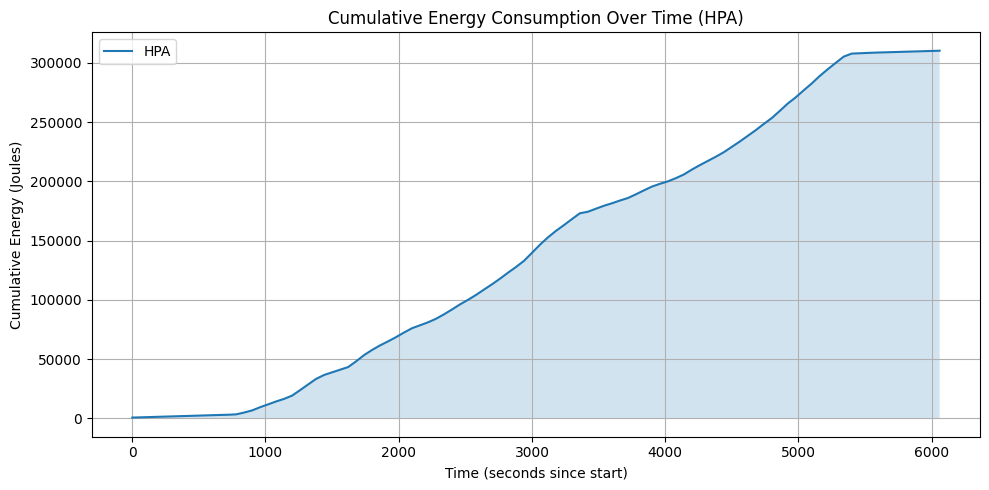

In [1]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# File path and label for the selected item
file_path = "hpa_2m/kepler_data.json"
label = "HPA"

# Storage for energy data
prev_energy = defaultdict(float)
energy_by_time = defaultdict(float)

min_timestamp = float("inf")
max_timestamp = float("-inf")

# Load and process data
with open(file_path, "r") as f:
    data = json.load(f)

for result in data["data"]["result"]:
    if result["metric"].get("container_namespace") != "default":
        continue

    pod = result["metric"].get("pod", "unknown")
    for ts_str, val_str in result["values"]:
        ts = int(ts_str)
        val = float(val_str)
        diff = max(0, val - prev_energy[pod])
        prev_energy[pod] = val

        energy_by_time[ts] += diff
        min_timestamp = min(min_timestamp, ts)
        max_timestamp = max(max_timestamp, ts)

# Prepare data for plotting
sorted_times = sorted(energy_by_time.keys())
cumulative_energy = []
total_energy = 0

for ts in sorted_times:
    total_energy += energy_by_time[ts]
    cumulative_energy.append(total_energy)

time_offsets = [t - sorted_times[0] for t in sorted_times]

# Plot energy consumption
plt.figure(figsize=(10, 5))
plt.plot(time_offsets, cumulative_energy, label=label)
plt.fill_between(time_offsets, cumulative_energy, alpha=0.2)
plt.xlabel("Time (seconds since start)")
plt.ylabel("Cumulative Energy (Joules)")
plt.title(f"Cumulative Energy Consumption Over Time ({label})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

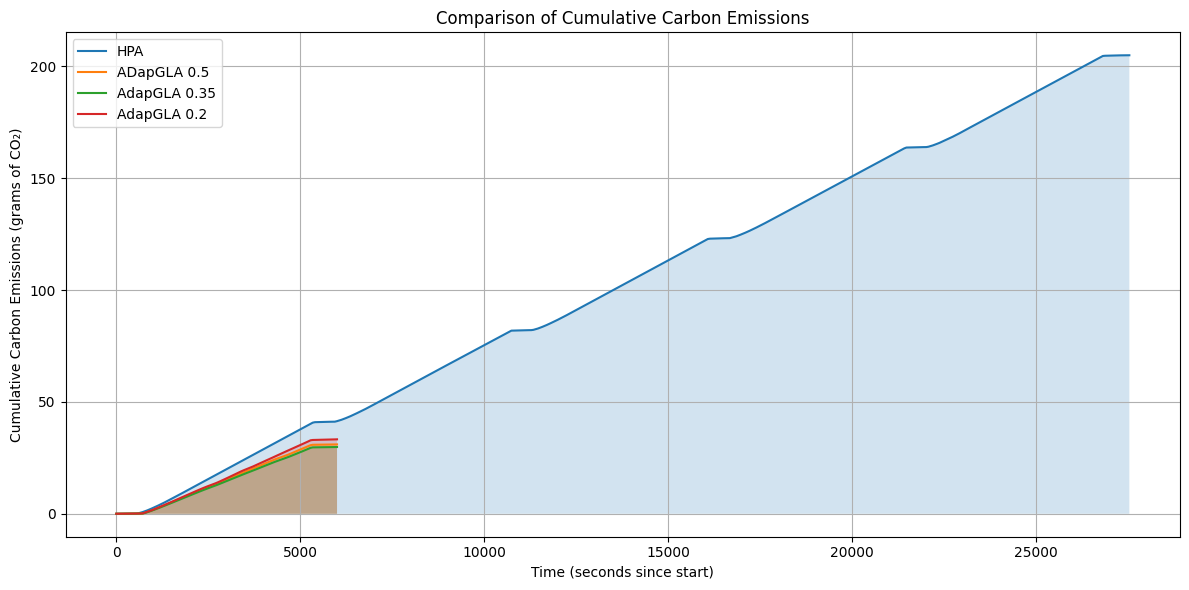

In [3]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict

# File paths and readable labels
file_paths = [
    #"hpa_2m/kepler_data.json",
    "bookinfo/hpa_dataset_phuc/kepler_data.json",
    "bookinfo/AdapGLA/AdapGLA_0.5_0/kepler_data.json",
    "bookinfo/AdapGLA/AdapGLA_0.35_0/kepler_data.json",
    "bookinfo/AdapGLA/AdapGLA_0.2_0/kepler_data.json"
    # "AdapGLA_30_5/kepler_data.json",
    # "AdapGLD_30_5/kepler_data.json",
    # "AdapGLT_30_5/kepler_data.json",
    # "GraphSAGE_30_5/kepler_data.json",
    # "AdapGLT_may_16/kepler_data.json",
    # "AdapGLA_30_5_04/kepler_data.json",
    # "AdapGLA_30_5_05/kepler_data.json",
    # "AdapGLA_30_5_08/kepler_data.json",
]

labels = [
    "HPA",
    "ADapGLA 0.5",
    "AdapGLA 0.35",
    "AdapGLA 0.2"
    #"HPA fresh",
    # "AdapGLA",
    # "AdapGLD",
    # "AdapGLT",
    # "AdapGLA_BMM",
    #"AdapGLT_may_16"
    # "AdapGLA t=0.4",
    # "AdapGLA t=0.5",
    # "AdapGLA t=0.8",
]

# Storage for energy profiles
all_energy_profiles = {}

# Process each file
for file_path, label in zip(file_paths, labels):
    with open(file_path, "r") as f:
        data = json.load(f)

    prev_energy = defaultdict(float)
    energy_by_time = defaultdict(float)
    min_timestamp = float("inf")

    for result in data["data"]["result"]:
        if result["metric"].get("container_namespace") != "default":
            continue

        pod = result["metric"].get("pod", "unknown")
        for ts_str, val_str in result["values"]:
            ts = int(ts_str)
            val = float(val_str)
            diff = max(0, val - prev_energy[pod])
            prev_energy[pod] = val

            energy_by_time[ts] += diff
            min_timestamp = min(min_timestamp, ts)

    sorted_times = sorted(energy_by_time.keys())
    cumulative_energy = []
    total_energy = 0

    for ts in sorted_times:
        total_energy += energy_by_time[ts]
        cumulative_energy.append(total_energy)

    time_offsets = [t - sorted_times[0] for t in sorted_times]
    all_energy_profiles[label] = (time_offsets, cumulative_energy)

# Plotting
plt.figure(figsize=(12, 6))

# Conversion: Joules to grams of CO2
conversion_factor = 6.472e-5  # grams of CO2 per Joule

# Plotting carbon emissions
plt.figure(figsize=(12, 6))

for label, (time_offsets, cumulative_energy) in all_energy_profiles.items():
    cumulative_emissions = [e * conversion_factor for e in cumulative_energy]
    plt.plot(time_offsets, cumulative_emissions, label=label)
    plt.fill_between(time_offsets, cumulative_emissions, alpha=0.2)

plt.xlabel("Time (seconds since start)")
plt.ylabel("Cumulative Carbon Emissions (grams of CO₂)")
plt.title("Comparison of Cumulative Carbon Emissions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_16082/2619906302.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("BuGn")


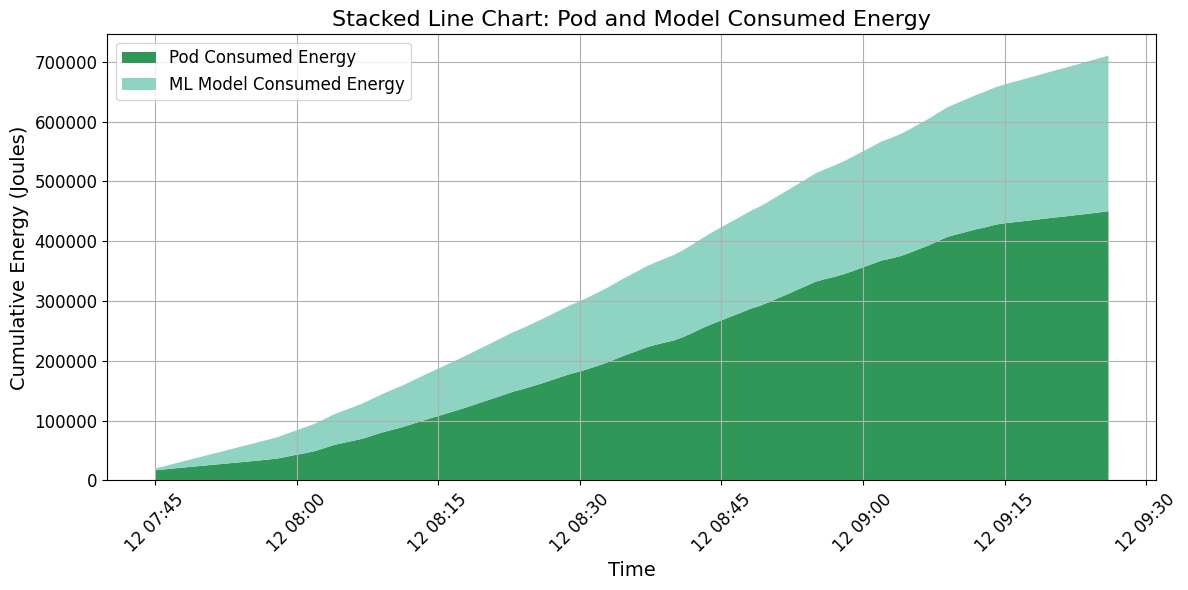

In [23]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
import numpy as np
from matplotlib.cm import get_cmap

# === Load Kepler pod energy data ===
kepler_file = "AdapGLA_30_5/kepler_data.json"
with open(kepler_file, "r") as f:
    data = json.load(f)

prev_energy = defaultdict(float)
energy_by_time = defaultdict(float)

for result in data["data"]["result"]:
    pod = result["metric"].get("pod", "unknown")
    container = result["metric"].get("container", "unknown")
    key = (pod, container)

    for ts_str, val_str in sorted(result["values"], key=lambda x: int(x[0])):
        ts = int(ts_str)
        val = float(val_str)
        diff = max(0, val - prev_energy[key])
        prev_energy[key] = val
        energy_by_time[ts] += diff

# Convert to cumulative energy list
sorted_times = sorted(energy_by_time.keys())
cumulative_pod_energy = []
total = 0
for ts in sorted_times:
    total += energy_by_time[ts]
    cumulative_pod_energy.append(total)

datetime_labels = [datetime.fromtimestamp(ts) for ts in sorted_times]

# === Load emissions data and convert to Joules ===
emissions_file = "AdapGLA_30_5/emissions_inference.csv"
emissions_df = pd.read_csv(emissions_file)
emissions_df["timestamp"] = pd.to_datetime(emissions_df["timestamp"])
emissions_df = emissions_df.sort_values("timestamp")

# Interpolate model energy to match pod timestamps
emissions_df["cpu_energy_joules"] = emissions_df["cpu_energy"] * 3.6e6
model_energy_interpolated = np.interp(
    [ts.timestamp() for ts in datetime_labels],
    emissions_df["timestamp"].astype(int) / 1e9,
    emissions_df["cpu_energy_joules"]
)

# === Plot Stacked Line Chart with BuGn color palette and increased font sizes ===
plt.figure(figsize=(12, 6))

cmap = get_cmap("BuGn")
colors = [cmap(i) for i in [0.7, 0.4]]  # Two distinct shades

plt.stackplot(datetime_labels,
              cumulative_pod_energy,
              model_energy_interpolated,
              labels=["Pod Consumed Energy", "ML Model Consumed Energy"],
              colors=colors)

plt.xlabel("Time", fontsize=14)
plt.ylabel("Cumulative Energy (Joules)", fontsize=14)
plt.title("Stacked Line Chart: Pod and Model Consumed Energy", fontsize=16)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()


In [7]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime, timedelta
import numpy as np
from matplotlib.cm import get_cmap

def load_kepler_energy(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)

    prev_energy = defaultdict(float)
    energy_by_time = defaultdict(float)

    for result in data["data"]["result"]:
        # if result["metric"].get("container_namespace") != "default":
        #     continue
        key = (result["metric"].get("pod", "unknown"), result["metric"].get("container", "unknown"))
        for ts_str, val_str in sorted(result["values"], key=lambda x: int(x[0])):
            ts = int(ts_str)
            val = float(val_str)
            diff = max(0, val - prev_energy[key])
            prev_energy[key] = val
            energy_by_time[ts] += diff

    sorted_times = sorted(energy_by_time.keys())
    cumulative_energy = np.cumsum([energy_by_time[ts] for ts in sorted_times])
    timestamps = [datetime.fromtimestamp(ts) for ts in sorted_times]
    return timestamps, cumulative_energy

def load_and_align_emissions(file_path, target_start_time):
    df = pd.read_csv(file_path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    time_shift = target_start_time - df["timestamp"].iloc[0]
    df["aligned_timestamp"] = df["timestamp"] + time_shift
    df["cpu_energy_joules"] = df["cpu_energy"] * 3.6e6
    return df

# Load and process kepler data for deepscaler
kepler_ts, kepler_energy = load_kepler_energy("AdapGLA/AdapGLB_0.35_1/kepler_data.json")
kepler_start_time = kepler_ts[0]

# Load and align emissions data
emissions_df = load_and_align_emissions("AdapGLA/emissions_inference_B.csv", kepler_start_time)
model_energy_interpolated = np.interp(
    [ts.timestamp() for ts in kepler_ts],
    emissions_df["aligned_timestamp"].astype(np.int64) / 1e9,
    emissions_df["cpu_energy_joules"]
)

# Total combined energy
total_energy = kepler_energy + model_energy_interpolated

# Load and align HPA kepler data
hpa_ts, hpa_energy = load_kepler_energy("hpa_2m/kepler_data.json")
hpa_time_shift = kepler_start_time - hpa_ts[0]
hpa_ts_aligned = [ts + hpa_time_shift for ts in hpa_ts]

# Compute total energies
total_energy_hpa = hpa_energy[-1]
total_energy_kepler = kepler_energy[-1]
model_energy_overhead = model_energy_interpolated[-1]
total_adapgla_energy = total_energy_kepler + model_energy_overhead

# Print results
print(f"Total consumed energy of HPA: {total_energy_hpa:.2f} J")
print(f"Total consumed energy of the Kepler: {total_energy_kepler:.2f} J")
print(f"Model energy overhead: {model_energy_overhead:.2f} J")
print(f"Total consumed energy of AdapGLA (Kepler + Model Overhead): {total_adapgla_energy:.2f} J")


# === Plot with BuGn colormap, increased font sizes, and green dashed total line ===
# plt.figure(figsize=(12, 6))
# cmap = get_cmap("BuGn")
# colors = [cmap(i) for i in [0.7, 0.4]]

# plt.stackplot(kepler_ts, kepler_energy, model_energy_interpolated,
#               labels=["Pod Consumed Energy - AdapGLA", "ML Model Consumed Energy"],
#               colors=colors)

# plt.plot(hpa_ts_aligned, hpa_energy, 'r--', label="Pod Consumed Energy(HPA)", linewidth=2)
# plt.plot(kepler_ts, total_energy, 'g--', label="Total Energy usage of AdapGLA, t=0.5", linewidth=2)

# plt.xlabel("Time", fontsize=14)
# plt.ylabel("Cumulative Energy (Joules)", fontsize=14)
# plt.title("Stacked Line Chart: Pod and Model Consumed Energy", fontsize=16)
# plt.xticks(rotation=45, fontsize=12)
# plt.yticks(fontsize=12)
# plt.legend(loc="upper left", fontsize=12)
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Total consumed energy of HPA: 439235.25 J
Total consumed energy of the Kepler: 330491.15 J
Model energy overhead: 258738.25 J
Total consumed energy of AdapGLA (Kepler + Model Overhead): 589229.40 J


Total consumed energy of HPA: 439235.25 J

GLA

Total consumed energy of the Kepler: 283756.84 J
Model energy overhead: 256181.89 J
Total consumed energy of AdapGLA (Kepler + Model Overhead): 539938.73 J

GLD

Total consumed energy of the Kepler: 254972.46 J
Model energy overhead: 257673.35 J
Total consumed energy of AdapGLA (Kepler + Model Overhead): 512645.81 J

GLT

Total consumed energy of the Kepler: 327132.40 J
Model energy overhead: 257675.91 J
Total consumed energy of AdapGLA (Kepler + Model Overhead): 584808.31 J

GLB 
Total consumed energy of the Kepler: 330491.15 J
Model energy overhead: 258738.25 J
Total consumed energy of AdapGLA (Kepler + Model Overhead): 589229.40 J


In [3]:
# Calculate total energy usage (using last cumulative value) for pods starting with "ts-"
total_energy = {}
for container, (timestamps, energy_values) in time_series.items():
    total = energy_values[-1]  # Take the last value (latest cumulative energy)
    total_energy[container] = total

# Sort and get top 10
top_10 = sorted(total_energy.items(), key=lambda x: x[1], reverse=True)[:10]

# Print top 10
print("Top 10 'ts-' Pods by Total Energy Usage:")
for i, (container, total) in enumerate(top_10, 1):
    print(f"{i}. {container}: {total:.2f} Joules")

# Print total energy usage across filtered pods
grand_total = sum(total_energy.values())
print(f"\nTotal Energy Usage Across 'ts-' Pods: {grand_total:.2f} Joules")

NameError: name 'time_series' is not defined

In [4]:
# Calculate total energy usage (using last cumulative value) for pods starting with "ts-"
total_energy = {}
for container, (timestamps, energy_values) in time_series.items():
    # if container.startswith("ts-"):  # Filter condition
        total = energy_values[-1]  # Take the last value (latest cumulative energy)
        total_energy[container] = total

# Sort and get top 10
top_10 = sorted(total_energy.items(), key=lambda x: x[1], reverse=True)[:10]

# Print top 10
print("Top 10 'ts-' Pods by Total Energy Usage:")
for i, (container, total) in enumerate(top_10, 1):
    print(f"{i}. {container}: {total:.2f} Joules")

# Print total energy usage across filtered pods
grand_total = sum(total_energy.values())
print(f"\nTotal Energy Usage Across 'ts-' Pods: {grand_total:.2f} Joules")

Top 10 'ts-' Pods by Total Energy Usage:
1. system_processes: 72480.04 Joules
2. kernel_processes: 25354.40 Joules
3. kube-apiserver: 8467.57 Joules
4. prometheus-server: 3758.14 Joules
5. kube-controller-manager: 3428.68 Joules
6. kepler-exporter: 3398.31 Joules
7. ts-basic-service: 3267.58 Joules
8. etcd: 3138.80 Joules
9. ts-ticketinfo-service: 3077.45 Joules
10. ts-travel-service: 2999.96 Joules

Total Energy Usage Across 'ts-' Pods: 175656.43 Joules


In [7]:
# Calculate total energy usage (using last cumulative value) for pods starting with "ts-"
total_energy = {}
for container, (timestamps, energy_values) in time_series.items():
    # if container.startswith("ts-"):  # Filter condition
        total = energy_values[-1]  # Take the last value (latest cumulative energy)
        total_energy[container] = total

# Sort and get top 10
top_10 = sorted(total_energy.items(), key=lambda x: x[1], reverse=True)[:10]

# Print top 10
print("Top 10 'ts-' Pods by Total Energy Usage:")
for i, (container, total) in enumerate(top_10, 1):
    print(f"{i}. {container}: {total:.2f} Joules")

# Print total energy usage across filtered pods
grand_total = sum(total_energy.values())
print(f"\nTotal Energy Usage Across 'ts-' Pods: {grand_total:.2f} Joules")


Top 10 'ts-' Pods by Total Energy Usage:
1. system_processes: 168437.06 Joules
2. kernel_processes: 30381.58 Joules
3. ts-station-mongo: 20121.91 Joules
4. kube-apiserver: 11896.78 Joules
5. ts-station-service: 7058.82 Joules
6. prometheus-server: 5366.36 Joules
7. kepler-exporter: 4796.22 Joules
8. ts-inside-payment-service: 4173.16 Joules
9. etcd: 3606.84 Joules
10. ts-travel-service: 3569.42 Joules

Total Energy Usage Across 'ts-' Pods: 312603.04 Joules
